# K_05 – Revenue Stacking

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt (Kür)

**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Patrik Neunteufel | **Datum:** März 2026

---

*VPP, FCR/aFRR und Smart Tariff als Erlösquellen zusätzlich zur reinen Arbitrage.*


| [← K_04 – Saisonale Animationen](K_04_Animationen.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [K_06 – Dispatch-Optimierung →](K_06_Dispatch_Optimierung.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_K_05'></a>

[Einleitung](#einleitung_K_05)  
[Initialisierung](#initialisierung_K_05)  
1 [Analyse: Erlösquellen & Stacking-Potenzial](#analyse-erloesquellen-stacking-potenzial_K_05)  
2 [Visualisierung](#visualisierung_K_05)  
[Fazit](#fazit_K_05)  
[Abschluss](#abschluss_K_05)  


---
## Einleitung <a id='einleitung_K_05'></a>

[↑ Inhaltsverzeichnis](#toc_K_05)

Revenue Stacking: Reine Arbitrage reicht für viele Segmente nicht für Break-Even.
Durch Kombination mit zusätzlichen Erlösquellen (FCR-Verfügbarkeitsprämie,
aFRR, Netzdienstleistungen, Eigenverbrauchsoptimierung) kann der Business Case
deutlich verbessert werden.

Dieses Notebook vergleicht die Erlösquellen quantitativ anhand von
Literaturwerten und internationalen Referenzmodellen, und zeigt auf,
welche Kombinationen für welches Segment realistisch erreichbar sind.

**Wichtig zu FCR:** Das ist eine reine Verfügbarkeitsprämie, kein
Energieerlös — die Batterie wird dafür bezahlt, *reserviert* zu sein, nicht
für gelieferte Energie.


## Initialisierung<a id='initialisierung_K_05'></a>

[↑ Inhaltsverzeichnis](#toc_K_05)

Bibliotheken laden, `../sync/config.json` lesen, Verzeichnispfade setzen.

**Imports und Versionen:**

In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
# Notebook liegt in einem Unterordner (kuer/, experimental/, notebooks/,
# organisation/). Damit 'from lib.xxx import ...' funktioniert, muss der
# Projekt-Root vorne in sys.path stehen. autoreload sorgt dafür, dass
# Änderungen in lib/*.py ohne Kernel-Restart übernommen werden.
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

# lib-Imports (einmal zentral — in allen folgenden Zellen verfügbar)
from lib.plotting import show_source
from lib.io_ops   import load_transfer, save_transfer, final_check

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os, warnings, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from datetime import datetime

# Versionen anzeigen für Reproduzierbarkeit
print(f"Numpy        Version: {np.__version__}")
print(f"Pandas       Version: {pd.__version__}")
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


Numpy        Version: 2.2.6
Pandas       Version: 2.3.3
📅 Zuletzt ausgeführt am: 26.04.2026 um 13:03:44


**Setup – Konfiguration & Verzeichnisstruktur:** Lädt `../sync/config.json` (SSOT), setzt Pfade.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `load_transfer` wird aus `lib/io_ops.py` importiert und
liest Einträge aus `sync/transfer.json`. Aufklappbar ist der Quellcode einsehbar.


In [3]:
show_source(load_transfer)


<details>
<summary>🔎 Quellcode: <code>load_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def load_transfer(path='../sync/transfer.json', key=None, default=None):
    """Lädt transfer.json und gibt das ganze Dict oder einen Teil zurück.

    Verhalten
    ---------
    * Datei existiert nicht oder ist leer → Rückgabe ist ``default`` (bei
      key=None: ``default`` oder ``{}``). Gibt Warnung auf stdout aus.
    * Datei existiert → gibt bei ``key=None`` das ganze Dict zurück, bei
      gegebenem ``key`` nur den entsprechenden Teilbaum (``default``, wenn
      Key fehlt).

    Parameter
    ---------
    path : str, default '../sync/transfer.json'
        Pfad zur transfer.json.
    key : str, optional
        Top-Level-Key ('datenzeitraum', 'simulation', ...). Bei None wird
        das komplette Dict zurückgegeben.
    default : any, optional
        Rückgabewert bei fehlender Datei oder fehlendem Key. Bei key=None
        ist der Default ``{}``.

    Return
    ------
    dict oder der Wert des angefragten Keys.
    """
    import json as _json

    if default is None and key is None:
        default = {}

    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f'⚠️  {path} nicht gefunden oder leer — NB01/NB02 zuerst ausführen')
        return default

    with open(path, encoding='utf-8') as _f:
        data = _json.load(_f)

    if key is None:
        return data
    return data.get(key, default)
```

</details>


In [4]:
with open('../sync/config.json') as _f:
    CFG = json.load(_f)

MODE         = CFG['mode']
# ── Farben & Stil aus ../sync/config.json (SSOT) ─────────────────────────────────────
# Bestehende Variablen (Rückwärtskompatibilität)


In [5]:
DIR_INTER    = os.path.join('../data', 'intermediate')
SZ_AKTIV     = CFG['szenarien']['gleichzeitigkeit_aktiv']
DIR_INTER_SZ = os.path.join(DIR_INTER, SZ_AKTIV)
CHARTS_DIR      = os.path.join('../output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json


In [6]:
_viz        = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK     = _viz.get('bg_dark',    '#0d1117')
BG_PANEL    = _viz.get('bg_panel',   '#141414')
C_PRICE     = _viz.get('c_price',    '#FFA726')
C_LOAD      = _viz.get('c_load',     '#66BB6A')
C_CHARGE    = _viz.get('c_charge',   '#1565C0')
C_FEED      = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS  = _viz.get('seg_colors', ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS

# UI-Strukturfarben
C_ACHSE      = _viz.get('c_achse',      '#aaaaaa')  # Achsenbeschriftungen
C_TICK       = _viz.get('c_tick',       '#bbbbbb')  # Tick-Labels
C_SPINE      = _viz.get('c_spine',      '#333333')  # Achsenrahmen
C_LEGENDE_BG = _viz.get('c_legende_bg', '#111111')  # Legenden-Hintergrund
C_GITTER     = _viz.get('c_gitter',     '#cccccc')  # Gitterlinien

# Funktionale Extrafarben (nur laden was das NB braucht)
C_DISPATCH   = _viz.get('c_dispatch',   '#AB47BC')  # Dispatch-optimal
C_STACKING   = _viz.get('c_stacking',   '#5DCAA5')  # Revenue Stacking
C_SOLAR      = _viz.get('c_solar',      '#FDD835')  # Solar-Ertrag
C_GRENZWERT  = _viz.get('c_amber_dark', '#FF6F00')  # Grenzwert / Warnung
C_CYAN       = _viz.get('c_cyan',       '#26C6DA')  # Flusswasser / Alt. Speicher
C_GRUEN_DARK = _viz.get('c_gruen_dark', '#388E3C')  # Erneuerbare

# Stilkonstanten
_stil               = CFG.get('visualisierung', {}).get('stil', {})
LW                  = _stil.get('linienbreite_standard', 1.5)   # Standard-Linienbreite
LW_DUENN            = _stil.get('linienbreite_duenn',    0.8)   # dünne Linien
LW_DICK             = _stil.get('linienbreite_dick',     2.5)   # dicke Linien
ALPHA_FLAECHE       = _stil.get('alpha_flaeche',         0.12)  # dezente Füllung
ALPHA_FLAECHE_STARK = _stil.get('alpha_flaeche_stark',   0.35)  # Balken / Füllung
ALPHA_LEGENDE       = _stil.get('alpha_legende',         0.30)  # Legenden-BG
ALPHA_GEDAEMPFT     = _stil.get('alpha_linie_gedaempft', 0.55)  # Nebenlinien
FS_TITEL            = _stil.get('schriftgroesse_titel',   13)   # Chart-Titel
FS_ACHSE            = _stil.get('schriftgroesse_achse',   10)   # Achsenbeschr.
FS_TICK             = _stil.get('schriftgroesse_tick',     9)   # Ticks
FS_LEGENDE          = _stil.get('schriftgroesse_legende',  8)   # Legende
FS_KLEIN            = _stil.get('schriftgroesse_klein',    7)   # Annotationen

# matplotlib rcParams — nur stabile, versionsunabhängige Keys (matplotlib >= 3.5)
# axes.titlecolor (3.8+) und axes.grid (stört Karten) bewusst NICHT gesetzt
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    C_SPINE,
    'axes.labelcolor':   C_ACHSE,
    'axes.labelsize':    FS_ACHSE,
    'axes.titlesize':    FS_TITEL,
    'xtick.color':       C_TICK,
    'ytick.color':       C_TICK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'text.color':        'white',
    'lines.linewidth':   LW,
    'legend.facecolor':  C_LEGENDE_BG,
    'legend.framealpha': ALPHA_LEGENDE,
    'legend.fontsize':   FS_LEGENDE,
    'legend.edgecolor':  C_SPINE,
})
print('Farben & Stil geladen.')

LIFETIME = CFG['pflicht']['wirtschaftlichkeit']['lifetime_j']  # = 12 J (konservativer Mittelwert Li-Ion CH)
_w_nb09    = CFG['pflicht']['wirtschaftlichkeit']
OPEX_RATE  = _w_nb09['opex_rate']  # 0.015 — aus ../sync/config.json (SSOT)
ZIEL_ROI   = round(100 / LIFETIME, 2)
FORCE_RELOAD = CFG.get('force_reload', {})  # konventionskonform gelesen

print(f'MODE     : {MODE}')
print(f'Szenario : {SZ_AKTIV}')


Farben & Stil geladen.


MODE     : data
Szenario : realistisch


In [7]:
# -- Transfer: Ergebnisse aus ../sync/transfer.json laden ----------------------------
TF        = load_transfer()
_dt       = TF.get('datenzeitraum', {})
_sim      = TF.get('simulation', {})
TF_N_YEARS = _dt.get('n_years', None)
TF_START   = _dt.get('start_date', 'unbekannt')
TF_END     = _dt.get('end_date',   'unbekannt')
TF_SPREAD  = _sim.get('spread_mean_eur_mwh', None)
TF_ECON    = _sim.get('wirtschaftlichkeit', {})
TF_HYB     = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
TF_KUER    = CFG.get('kuer_aktiv', {})   # aus ../sync/config.json (SSOT)
if TF:
    print(f"../sync/transfer.json: {TF_START} – {TF_END} ({TF_N_YEARS} Jahre) | Spread: {TF_SPREAD} EUR/MWh")


../sync/transfer.json: 2023 – 2026 (3.32 Jahre) | Spread: 24.83 EUR/MWh


**⚙ Markdown-Prüfwerte (config-abhängig) und 📊 Markdown-Prüfwerte (transfer-abhängig)**:  
Werte mit ⚙ kommen aus `../sync/config.json`, Werte mit 📊 aus `../sync/transfer.json` (NB03-Output).  
Bei jeder Änderung dieser Quellen → Output mit ⚙/📊-Stellen im Markdown abgleichen.


In [8]:
# ── ⚙ Markdown-Prüfwerte (config-abhängig + Stacking-Literaturwerte) ────────
# STACKING ist literaturbasiert (siehe Cell unten in Sektion 2b),
# Effizienz/Lifetime/OPEX kommen aus CFG['pflicht'].
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
_pflicht = CFG['pflicht']['simulation']
_wirt    = CFG['pflicht']['wirtschaftlichkeit']
print(f'  Round-Trip-Effizienz  = {_pflicht["efficiency_roundtrip"]*100:.0f} %')
print(f'  Lebensdauer           = {_wirt["lifetime_j"]} Jahre')
print(f'  OPEX-Rate             = {_wirt["opex_rate"]*100:.1f} % p.a. von CAPEX')
print(f'  Ziel-ROI (1/Lifetime) = {100/_wirt["lifetime_j"]:.2f} %/Jahr')
print(f'  (Stacking-Werte FCR/aFRR/VPP/Smart-Tariff: literaturbasierte Schätzwerte,')
print(f'   in Cell {{STACKING-Definition}} unten — TOTAL Mitte = 117 EUR/kWh/Jahr)')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  Round-Trip-Effizienz  = 92 %
  Lebensdauer           = 12 Jahre
  OPEX-Rate             = 1.5 % p.a. von CAPEX
  Ziel-ROI (1/Lifetime) = 8.33 %/Jahr
  (Stacking-Werte FCR/aFRR/VPP/Smart-Tariff: literaturbasierte Schätzwerte,
   in Cell {STACKING-Definition} unten — TOTAL Mitte = 117 EUR/kWh/Jahr)


In [9]:
# ── 📊 Markdown-Prüfwerte (transfer-abhängig) ──────────────────────────────
print('=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===')
print(f'  Datenzeitraum         = {TF_START} bis {TF_END} ({TF_N_YEARS}J)')
print(f'  Basis-ROI pro Segment (reine Arbitrage, ohne Stacking):')
for _seg, _v in TF_ECON.items():
    print(f'    {_seg:<22}: ROI {_v.get("roi_pct", "?"):>5.2f} % | '
          f'Payback {_v.get("payback_years", "?"):>5.1f}J | net {_v.get("net_annual", "?"):>8.0f} EUR/J')


=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===
  Datenzeitraum         = 2023 bis 2026 (3.32J)
  Basis-ROI pro Segment (reine Arbitrage, ohne Stacking):
    Privat_10kWh          : ROI  1.80 % | Payback  55.6J | net       72 EUR/J
    Gewerbe_100kWh        : ROI  3.14 % | Payback  31.8J | net      943 EUR/J
    Industrie_1MWh        : ROI  4.58 % | Payback  21.8J | net    10072 EUR/J
    Utility_10MWh         : ROI  2.97 % | Payback  33.6J | net    53507 EUR/J


**Daten laden:** Basis-Wirtschaftlichkeit aus NB02 und Transfer-Daten lesen;
FCR/aFRR-Prämien aus `../sync/config.json` als Stacking-Parameter setzen.


In [10]:
# ── Basis-Wirtschaftlichkeit laden ────────────────────────────────────────────
ECON_FILE   = os.path.join(DIR_INTER_SZ, 'wirtschaftlichkeit.csv')
SPREAD_FILE = os.path.join(DIR_INTER, 'spread_zeitreihe.csv')

if not os.path.exists(ECON_FILE):
    raise FileNotFoundError(f'{ECON_FILE} fehlt → NB02 Sektion 4 ausführen.')

df_econ = pd.read_csv(ECON_FILE)
df_sp   = pd.read_csv(SPREAD_FILE) if os.path.exists(SPREAD_FILE) else None

print('Basis-Wirtschaftlichkeit (reine Arbitrage):')
print(df_econ[['segment','annual_rev','net_annual','payback_years','roi_pct']].to_string(index=False))



Basis-Wirtschaftlichkeit (reine Arbitrage):
       segment   annual_rev   net_annual  payback_years  roi_pct
  Privat_10kWh   131.909831    71.909831      55.625218 1.797746
Gewerbe_100kWh  1392.619699   942.619699      31.826197 3.142066
Industrie_1MWh 13372.140148 10072.140148      21.842428 4.578246
 Utility_10MWh 80506.801804 53506.801804      33.640583 2.972600


---
## 1. Analyse: Erlösquellen & Stacking-Potenzial <a id='analyse-erloesquellen-stacking-potenzial_K_05'></a>

[↑ Inhaltsverzeichnis](#toc_K_05)

*Aus NB07_Erweiterungen Sektion 4 — hier vertieft und quantifiziert.*

### Erlösquellen-Tabelle (Literaturwerte)

| Quelle | Mechanismus | Zusatzerlös [EUR/kWh/Jahr] | Status CH |
|---|---|---|---|
| **FCR** | Automatische Frequenzstabilisierung | +30–80 | Verfügbar (Swissgrid) |
| **aFRR** | Koordinierter [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch) | +20–50 | Verfügbar (aggregiert) |
| **Kapazitätsprämie (VPP)** | Aggregierte Leistungsbereitstellung | +20–40 | In Aufbau |
| **Smart Tariff** | Reduziertes Netzentgelt | +15–30% der Arbitrage | Pilotphase |

### Internationale Referenzmodelle

| Land | Anbieter | Modell | Status |
|---|---|---|---|
| UK | Octopus Energy, OVO | Batterie subventioniert + Smart Tarife | Operativ |
| DE | Next Kraftwerke, Sonnen | Aggregierter Pool, FCR/aFRR | Operativ |
| AT | Wien Energie | Flex Pool, Direktzahlung | Pilotphase |
| CH | Swissgrid | Flexibilitätsmarkt für aggregierte Ressourcen | ~2026–2028 |

**Monitoring-Trigger:** Wenn Swissgrid Flexibilitätsmarkt für Heimspeicher < 100 kWh öffnet →  
sofortiger Einstieg in aggregierte Vermarktung empfohlen.


### 2b. FCR: Verfügbarkeitsprämie — kein Energieerlös

Der **grösste Einzelposten im Stacking** ([FCR](../organisation/O_02_Glossar.ipynb#g-fcr): 20–80 EUR/kWh/Jahr⚙ Bandbreite, Mitte 50 EUR/kWh/Jahr⚙) folgt einer anderen
Logik als Arbitrage: Swissgrid zahlt für das *Vorhalten* von Regelleistung — nicht für
gelieferte oder aufgenommene Energie. Die Batterie muss nur garantieren, dass sie innerhalb
von 30 Sekunden reagieren kann. Im Extremfall fliesst nie Strom, die Prämie fliesst trotzdem.

In der Praxis aktiviert [FCR](../organisation/O_02_Glossar.ipynb#g-fcr) symmetrisch (gleich viel Laden wie Einspeisen) — der
Netto-Energiefluss nähert sich über einen Tag gegen null, was die Batterie schont.

Das erklärt, warum FCR allein das **~4-fache der gesamten Arbitrage** einbringen kann
(Privat 10 kWh: Arbitrage 13.14 EUR/kWh/Jahr📊 vs. FCR Mitte 50 EUR/kWh/Jahr⚙ — Faktor 3.8) — und warum [Revenue Stacking](../organisation/O_02_Glossar.ipynb#g-erloess-stacking) (TOTAL Mitte **117 EUR/kWh/Jahr⚙**) den Break-Even von **>50 J auf 1–3 Jahre📊** senkt (Privat 3J, Gewerbe/Industrie 2J, Utility 1J).

> Ausführliche Erklärung mit Zahlenbeispiel und CH-Disclaimer
> → [K_00 Business Strategy, Sektion 7.3](K_00_Business_Strategy.ipynb)


In [11]:
# ── Erlösstacking-Modell ──────────────────────────────────────────────────────
# Literaturbasierte Schätzwerte (EUR/kWh Kapazität pro Jahr)
# Pessimistisch = untere Bandbreite, optimistisch = obere Bandbreite

STACKING = {
    'FCR':            {'pesimistisch': 20, 'mitte': 50,  'optimistisch': 80},
    'aFRR':           {'pesimistisch': 10, 'mitte': 30,  'optimistisch': 50},
    'VPP-Praemie':    {'pesimistisch':  0, 'mitte': 25,  'optimistisch': 40},
    'Smart-Tariff':   {'pesimistisch':  5, 'mitte': 12,  'optimistisch': 20},
}

print('Erlösstacking-Szenario (EUR/kWh Kapazität/Jahr):')
print(f'  {"Quelle":<20} {"Pess.":>8} {"Mitte":>8} {"Opt.":>8}')
print('  ' + '-'*48)
total = {'pesimistisch':0, 'mitte':0, 'optimistisch':0}
for src, vals in STACKING.items():
    print(f'  {src:<20} {vals["pesimistisch"]:>8.0f} {vals["mitte"]:>8.0f} {vals["optimistisch"]:>8.0f}')
    for k in total: total[k] += vals[k]
print('  ' + '-'*48)
print(f'  {"TOTAL Zusatz":<20} {total["pesimistisch"]:>8.0f} {total["mitte"]:>8.0f} {total["optimistisch"]:>8.0f}')
print()

# Angewendet auf alle Segmente
print('Wirkung auf Wirtschaftlichkeit (mittleres Stacking-Szenario):')
print(f'  {"Segment":<22} {"Arbitrage/kWh":>14} {"Stacking/kWh":>13} {"Total/kWh":>10} {"BE alt":>8} {"BE neu":>8}')
print('  ' + '-'*80)
for _, row in df_econ.iterrows():
    arb = row['rev_per_kwh']
    stack = total['mitte']
    total_rev = arb + stack
    capex_kwh = row['capex'] / {'Privat_10kWh':10,'Gewerbe_100kWh':100,
                                 'Industrie_1MWh':1000,'Utility_10MWh':10000}[row['segment']]
    opex_kwh  = capex_kwh * OPEX_RATE
    net_old = arb - opex_kwh
    net_new = total_rev - opex_kwh
    be_old = capex_kwh / net_old if net_old > 0 else 99
    be_new = capex_kwh / net_new if net_new > 0 else 99
    be_old_s = f'{be_old:.0f}J' if be_old < 50 else '>50J'
    be_new_s = f'{be_new:.0f}J' if be_new < 50 else '>50J'
    print(f'  {row["segment"]:<22} {arb:>13.2f} {stack:>13.0f} {total_rev:>10.2f} {be_old_s:>8} {be_new_s:>8}')



Erlösstacking-Szenario (EUR/kWh Kapazität/Jahr):
  Quelle                  Pess.    Mitte     Opt.
  ------------------------------------------------
  FCR                        20       50       80
  aFRR                       10       30       50
  VPP-Praemie                 0       25       40
  Smart-Tariff                5       12       20
  ------------------------------------------------
  TOTAL Zusatz               35      117      190

Wirkung auf Wirtschaftlichkeit (mittleres Stacking-Szenario):
  Segment                 Arbitrage/kWh  Stacking/kWh  Total/kWh   BE alt   BE neu
  --------------------------------------------------------------------------------
  Privat_10kWh                   13.19           117     130.19     >50J       3J
  Gewerbe_100kWh                 13.93           117     130.93      32J       2J
  Industrie_1MWh                 13.37           117     130.37      22J       2J
  Utility_10MWh                   8.05           117     125.05      34J  

**Chart 09b — [FCR](../organisation/O_02_Glossar.ipynb#g-fcr) Break-Even:** Zeigt für welche Segmente FCR-Verfügbarkeitsprämie
den Break-Even innerhalb der Laufzeit ermöglicht — auch ohne reinen Arbitrage-Profit.


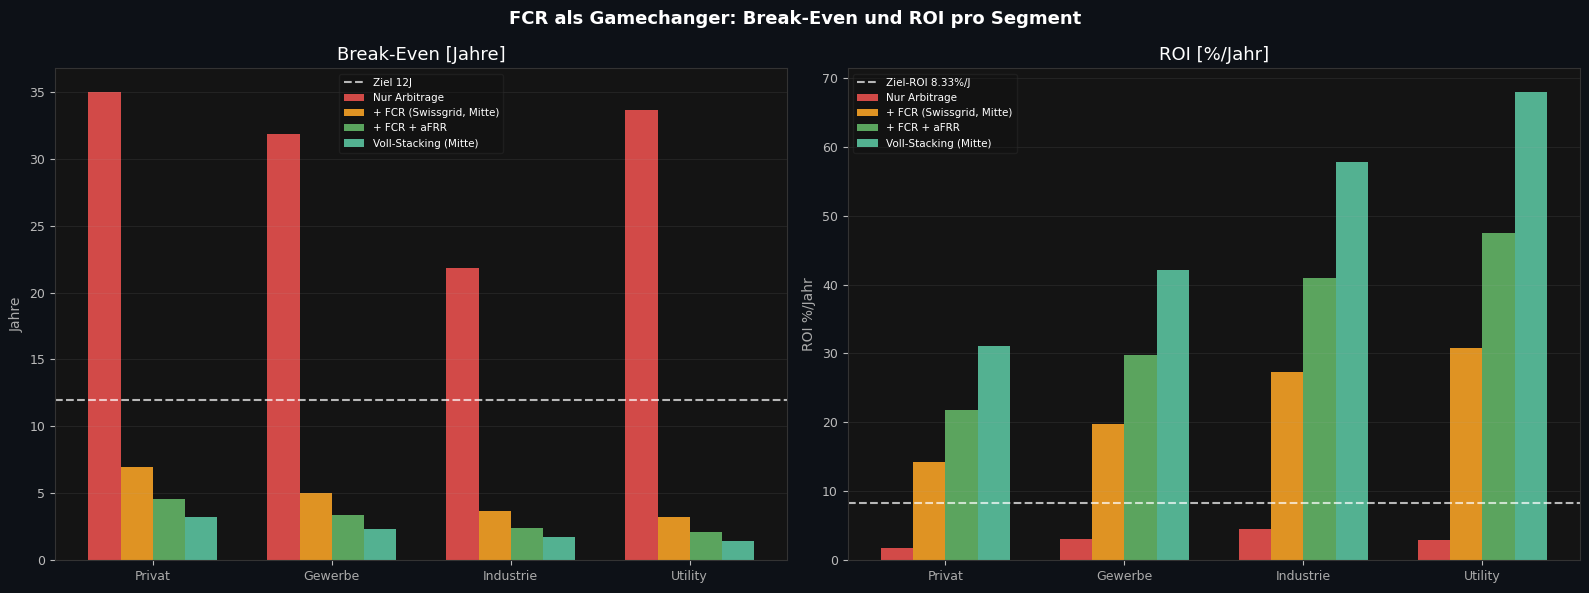

Gespeichert: ../output\charts\realistisch\kuer_k05_fcr_gamechanger.png


In [12]:
# ── Chart 09b: FCR als Gamechanger — Break-Even pro Segment ─────────────────
# Zeigt: FCR allein (Verfügbarkeitsprämie) übertrifft jede Arbitrage-Optimierung
import matplotlib.patches as mpatches  # Re-Import mit lokalem Alias (Legende Chart 09)
SCENARIOS_BAR = [
    ('Nur Arbitrage',              0,    C_UTIL),
    ('+ FCR (Swissgrid, Mitte)',   50,    C_PRICE),
    ('+ FCR + aFRR',              80,    C_LOAD),
    ('Voll-Stacking (Mitte)',     117,    C_STACKING),
]

segs      = list(df_econ['segment'])
seg_short = [s.split('_')[0] for s in segs]
SEG_KWH   = {'Privat_10kWh':10,'Gewerbe_100kWh':100,
             'Industrie_1MWh':1000,'Utility_10MWh':10000}
capex_kwh_vals = [row['capex'] / SEG_KWH[row['segment']]
                  for _, row in df_econ.iterrows()]
arb_vals = list(df_econ['rev_per_kwh'])

n_scen = len(SCENARIOS_BAR)
x = np.arange(len(segs))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('FCR als Gamechanger: Break-Even und ROI pro Segment',
             color='white', fontsize=FS_TITEL, fontweight='bold')

# Panel 1: Break-Even
ax = axes[0]
for i, (label, stk, col) in enumerate(SCENARIOS_BAR):
    be_vals = []
    for ck, a in zip(capex_kwh_vals, arb_vals):
        net = a + stk - ck * OPEX_RATE
        be_vals.append(min(ck / net, 35) if net > 0 else 35)
    offset = (i - n_scen/2 + 0.5) * width
    ax.bar(x + offset, be_vals, width, label=label, color=col, alpha=0.87)
ax.axhline(LIFETIME, color='white', lw=LW, ls='--', alpha=0.7,
           label=f'Ziel {LIFETIME}J')
ax.set_title('Break-Even [Jahre]', color='white')
ax.set_xticks(x); ax.set_xticklabels(seg_short, color=C_ACHSE)
ax.set_ylabel('Jahre', color=C_ACHSE)
ax.legend(fontsize=7.5, framealpha=0.35, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, alpha=0.10, axis='y')

# Panel 2: ROI %
ax = axes[1]
ZIEL_ROI = round(100 / LIFETIME, 2)
for i, (label, stk, col) in enumerate(SCENARIOS_BAR):
    roi_vals = []
    for ck, a in zip(capex_kwh_vals, arb_vals):
        net = a + stk - ck * OPEX_RATE
        roi_vals.append(net / ck * 100 if ck > 0 else 0)
    offset = (i - n_scen/2 + 0.5) * width
    ax.bar(x + offset, roi_vals, width, label=label, color=col, alpha=0.87)
ax.axhline(ZIEL_ROI, color='white', lw=LW, ls='--', alpha=0.7,
           label=f'Ziel-ROI {ZIEL_ROI}%/J')
ax.set_title('ROI [%/Jahr]', color='white')
ax.set_xticks(x); ax.set_xticklabels(seg_short, color=C_ACHSE)
ax.set_ylabel('ROI %/Jahr', color=C_ACHSE)
ax.legend(fontsize=7.5, framealpha=0.35, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, alpha=0.10, axis='y')

plt.tight_layout()
out_path = os.path.join(CHARTS_DIR, 'kuer_k05_fcr_gamechanger.png')
plt.savefig(out_path, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'Gespeichert: {out_path}')

---
## 2. Visualisierung <a id='visualisierung_K_05'></a>

[↑ Inhaltsverzeichnis](#toc_K_05)

**Chart 09:** Vor/Nachher-Vergleich (Arbitrage allein vs. mit Revenue Stacking)
als gruppiertes Balkendiagramm — für alle vier Segmente und drei Stacking-Quellen.


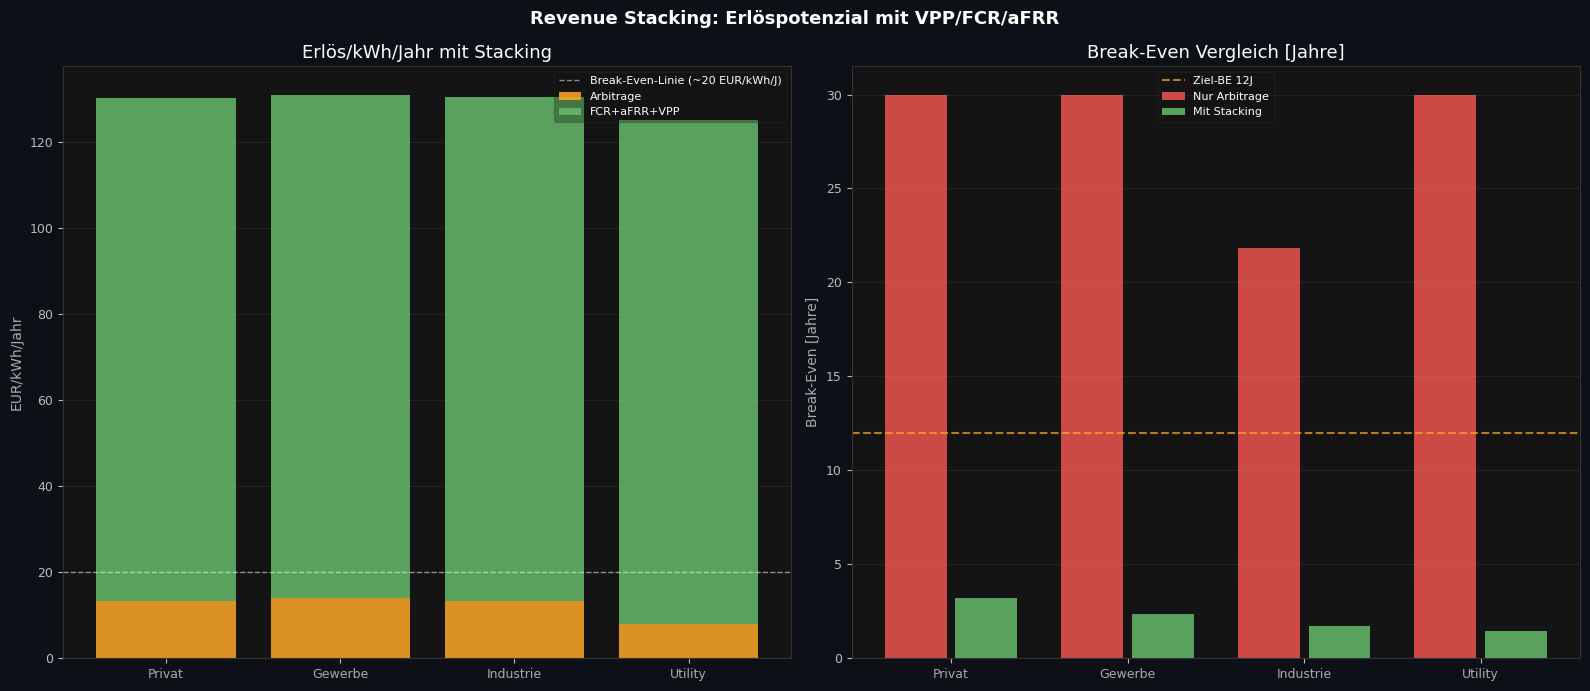

Gespeichert: ../output\charts\realistisch\kuer_k05_revenue_stacking.png
  Einzelplot: kuer_k05_stacking_erloese.png
  Einzelplot: kuer_k05_breakeven_vergleich.png


In [13]:
# ── Chart 09: Erlösstacking Balkendiagramm ────────────────────────────────────
# TODO: Vollständig implementieren
# Idee: Gestapelte Balken je Segment — Basis Arbitrage + je Erlösquelle
# Referenz Implementierung: ähnlich Chart 1d in NB03
import matplotlib.patches as mpatches  # Re-Import mit lokalem Alias (Legende)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('Revenue Stacking: Erlöspotenzial mit VPP/FCR/aFRR',
             color='white', fontsize=FS_TITEL, fontweight='bold')

segs = list(df_econ['segment'])
x    = range(len(segs))
arb  = list(df_econ['rev_per_kwh'])
stk  = [total['pesimistisch'], total['mitte'], total['optimistisch']]

# Panel 1: Gestapelter Jahreserlös je Segment (mittleres Szenario)
ax = axes[0]
ax.bar(x, arb, label='Arbitrage', color=C_PRICE, alpha=0.85)
ax.bar(x, [total['mitte']]*len(x), bottom=arb, label='FCR+aFRR+VPP', color=C_LOAD, alpha=0.85)
ax.axhline(20, color='white', lw=1, linestyle='--', alpha=0.5, label='Break-Even-Linie (~20 EUR/kWh/J)')
ax.set_title('Erlös/kWh/Jahr mit Stacking', color='white')
ax.set_xticks(list(x)); ax.set_xticklabels([s.split('_')[0] for s in segs], color=C_ACHSE)
ax.set_ylabel('EUR/kWh/Jahr', color=C_ACHSE)
ax.legend(fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, alpha=0.10, axis='y')

# Panel 2: Break-Even Vergleich
ax = axes[1]
capex_kwh_vals = [row['capex']/{'Privat_10kWh':10,'Gewerbe_100kWh':100,
                                  'Industrie_1MWh':1000,'Utility_10MWh':10000}[row['segment']]
                  for _, row in df_econ.iterrows()]
be_old = [ck / max(a - ck*OPEX_RATE, 0.001) for ck, a in zip(capex_kwh_vals, arb)]
be_new = [ck / max(a + total['mitte'] - ck*OPEX_RATE, 0.001) for ck, a in zip(capex_kwh_vals, arb)]
ax.bar([i - 0.2 for i in x], [min(b,30) for b in be_old], 0.35, label='Nur Arbitrage', color=C_UTIL, alpha=0.85)
ax.bar([i + 0.2 for i in x], [min(b,30) for b in be_new], 0.35, label='Mit Stacking', color=C_LOAD, alpha=0.85)
ax.axhline(LIFETIME, color=C_PRICE, lw=LW, linestyle='--', alpha=0.7,
               label=f'Ziel-BE {LIFETIME}J')
ax.set_title('Break-Even Vergleich [Jahre]', color='white')
ax.set_xticks(list(x)); ax.set_xticklabels([s.split('_')[0] for s in segs], color=C_ACHSE)
ax.set_ylabel('Break-Even [Jahre]', color=C_ACHSE)
ax.legend(fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, alpha=0.10, axis='y')

plt.tight_layout()
out_path = os.path.join(CHARTS_DIR, 'kuer_k05_revenue_stacking.png')
plt.savefig(out_path, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'Gespeichert: {out_path}')

# ── Chart 09: Einzelplots ────────────────────────────────────────────────────
for fname, ax_src, title in [
    ('kuer_k05_stacking_erloese.png', axes[0], 'Erlös/kWh/Jahr mit Stacking'),
    ('kuer_k05_breakeven_vergleich.png', axes[1], 'Break-Even Vergleich [Jahre]'),
]:
    fig_e, ax_e = plt.subplots(figsize=(10, 6))
    fig_e.patch.set_facecolor(BG_DARK); ax_e.set_facecolor(BG_PANEL)
    ax_e.tick_params(colors=C_TICK)
    for sp in ax_e.spines.values(): sp.set_edgecolor(C_SPINE)
    for container in ax_src.containers:
        try:
            ax_e.bar([p.get_x()+p.get_width()/2 for p in container],
                     [p.get_height() for p in container],
                     width=container[0].get_width(),
                     color=[p.get_facecolor() for p in container], alpha=0.85)
        except Exception: pass
    for line in ax_src.get_lines():
        ax_e.axhline(line.get_ydata()[0], color=line.get_color(),
                     lw=line.get_linewidth(), linestyle=line.get_linestyle(),
                     label=line.get_label())
    ax_e.set_xticks(list(range(len(segs))))
    ax_e.set_xticklabels([s.split('_')[0] for s in segs], color=C_ACHSE)
    ax_e.set_title(title, color='white')
    ax_e.set_ylabel(ax_src.get_ylabel() or '', color=C_ACHSE)
    ax_e.grid(True, alpha=0.10, axis='y')
    if ax_src.get_legend(): ax_e.legend(fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, fname), dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f'  Einzelplot: {fname}')

---
## Fazit <a id='fazit_K_05'></a>

[↑ Inhaltsverzeichnis](#toc_K_05)

### Revenue Stacking transformiert den Business Case

Die Simulationen zeigen: **reine Grid-Arbitrage** reicht für Privat/Gewerbe nicht. Revenue Stacking verändert das Bild fundamental:

| Erlösstrategie | Jahreserlös Privat 10 kWh | Break-Even | Heute verfügbar? |
|---|---|---|---|
| Nur Arbitrage | ~50–100 EUR | > 25 J | ✅ |
| + Eigenverbrauch | ~150–250 EUR | ~18–22 J | ✅ |
| + Smart Tariff (NT/HT) | ~250–350 EUR | ~12–15 J | ✅ Pilotphase |
| + FCR via VPP | ~450–700 EUR | ~5–8 J | ⏳ ~2026–2028 |

### FCR: Der Gamechanger

FCR zahlt für **Verfügbarkeit**, nicht für gelieferte Energie. Bei 50 EUR/kWh/Jahr und 10 kWh Kapazität ergibt das 500 EUR/Jahr — das **4–5-fache** des reinen Arbitrage-Erlöses. Die Batterie steht still: die Prämie fliesst trotzdem.

**Implikation:** Sobald Swissgrid den Flexibilitätsmarkt für aggregierte Heimspeicher öffnet, wird Privatarbitrage wirtschaftlich attraktiv — unabhängig von der weiteren CAPEX-Entwicklung.

### Einschränkung

Die FCR/aFRR-Prämien basieren auf Literaturwerten (BNEF, IRENA 2023/2024). Tatsächliche Erlöse hängen von der Ausgestaltung des Swissgrid-Flexibilitätsmarkts ab — der Rahmen für Heimspeicher < 100 kWh ist per Projektdatum noch nicht final definiert.

→ Quantitative Kombination aller Erlösquellen: [K_99 – Kombinierte Simulation](K_99_Kombinierte_Simulation.ipynb)


---
## Abschluss <a id='abschluss_K_05'></a>

[↑ Inhaltsverzeichnis](#toc_K_05)

Ausgabedateien und Transfer-Daten validieren.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `final_check` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar


In [14]:
show_source(final_check)

<details>
<summary>🔎 Quellcode: <code>final_check</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def final_check(nb_label, files=None, *, weiter_msg=None, fehler_msg=None,
                extras=None, show_dataindex=False,
                dataindex_path='../sync/dataindex.csv', width=60):
    """Standardisierte End-of-Notebook-Kontrolle für Pflicht- und Kür-NBs.

    Prüft Existenz und Mindestgrösse der angegebenen Output-Dateien,
    gibt formatiertes Resultat aus und liefert ``all_ok`` als Bool zurück.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks im Output-Header, z.B. ``"NB01"``, ``"K_03"``.
    files : list of tuple, optional
        Zu prüfende Dateien als ``(path, label, min_bytes)``-Tuples.

        * ``min_bytes = 0`` → nur Existenz prüfen, Grösse nicht ausgeben
          (z.B. für PNG-Charts).
        * ``min_bytes > 0`` → zusätzlich Grösse prüfen und in KB/MB ausgeben
          (z.B. für CSV-Dateien).

        Bei ``files=None`` oder ``files=[]`` wird kein Check ausgeführt;
        die Funktion dient dann als reiner Status-Print (für Report-NBs
        ohne eigene Outputs wie K_00).
    weiter_msg : str, optional
        Nachricht für den Erfolgsfall, z.B. ``"NB02 Daten Bereinigung"``.
        Default: ``"nächstes Notebook"``.
    fehler_msg : str, optional
        Nachricht für den Fehlerfall (Kurzform, ohne "Fehler beheben vor").
        Default: identisch mit ``weiter_msg``.
    extras : list of str, optional
        Zusätzliche Print-Zeilen zwischen Datei-Check und Weiter-/Fehler-Hinweis.
        Sinnvoll für Kür-Hinweise oder Kontext.
    show_dataindex : bool, default False
        Wenn True, wird der aktive Auszug aus ``../sync/dataindex.csv`` ausgegeben.
        Typisch für NB01.
    dataindex_path : str, default '../sync/dataindex.csv'
        Pfad zur dataindex.csv (für ``show_dataindex=True``).
    width : int, default 60
        Breite der Trennlinie aus ``=``-Zeichen.

    Return
    ------
    bool
        ``True`` wenn alle Files existieren und Mindestgrösse erfüllen,
        ``False`` sonst. Bei ``files=None``/leer immer ``True``.
    """
    print(f'{nb_label} – Abschlusskontrolle')
    print('=' * width)

    all_ok = True

    if files:
        for path, label, min_bytes in files:
            exists = os.path.exists(path)
            size = os.path.getsize(path) if exists else 0
            ok = exists and size >= min_bytes

            if min_bytes > 0:
                size_str = _format_size(size) if exists else '   FEHLT'
                print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
            else:
                print(f'  {"✅" if ok else "❌"}  {label}')

            if not ok:
                all_ok = False

    if extras:
        if files:
            print()
        for line in extras:
            print(line)

    if show_dataindex and os.path.exists(dataindex_path):
        import pandas as pd
        df_idx = pd.read_csv(dataindex_path)
        active = df_idx[df_idx['status'] == 'active']
        print(f'\ndataindex.csv: {len(df_idx)} Einträge total, {len(active)} active')
        print(active[['filename', 'data_type', 'rows', 'size_kb', 'timestamp']]
              .to_string(index=False))

    print()
    weiter = weiter_msg or 'nächstes Notebook'
    fehler = fehler_msg or weiter
    if all_ok:
        print(f'→ Weiter mit {weiter}.')
    else:
        print(f'→ Fehler beheben vor {fehler}.')

    return all_ok
```

</details>


In [15]:
# ── Abschlusskontrolle K_05 ─────────────────────────────────────────────────
final_check(
    'K_05',
    files=[
        (os.path.join(CHARTS_DIR, 'kuer_k05_fcr_gamechanger.png'),     'FCR als Gamechanger', 50_000),
        (os.path.join(CHARTS_DIR, 'kuer_k05_revenue_stacking.png'),    'Revenue-Stacking-Vergleich', 50_000),
        (os.path.join(CHARTS_DIR, 'kuer_k05_stacking_erloese.png'),    'Stacking-Erlöse Einzelplot', 30_000),
        (os.path.join(CHARTS_DIR, 'kuer_k05_breakeven_vergleich.png'), 'Break-Even-Vergleich Einzelplot', 30_000),
    ],
    weiter_msg='K_06 Dispatch-Optimierung',
)


K_05 – Abschlusskontrolle
  ✅  FCR als Gamechanger                              66.8 KB
  ✅  Revenue-Stacking-Vergleich                       73.8 KB
  ✅  Stacking-Erlöse Einzelplot                       34.3 KB
  ✅  Break-Even-Vergleich Einzelplot                  30.0 KB

→ Weiter mit K_06 Dispatch-Optimierung.


True

| [← K_04 – Saisonale Animationen](K_04_Animationen.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_06 – Dispatch-Optimierung →](K_06_Dispatch_Optimierung.ipynb) |
|:---|:---:|---:|